# **Project Name**    - Yes Bank Stock Closing Price Prediction

##### **Project Type**    - EDA + Regression Machine Learning
##### **Contribution**    - Individual
##### **Team Member 1 -** Garima Pachouri

# **Project Summary -**

This project focuses on analyzing and predicting the monthly closing stock price of Yes Bank using historical stock market data. The dataset contains monthly Open, High, Low and Close prices from July 2005 onward. The target variable for this project is **Close**, because closing price is one of the most important indicators used by investors, traders and analysts to understand the final market value of a stock for a specific trading period.

The project was completed in a structured data-engineering and machine-learning workflow. First, the dataset was loaded safely with exception handling so that the notebook can run in one go without errors. Then the data was inspected using first view, shape, information, duplicate check, missing value check and unique value analysis. The Date column was converted into proper datetime format and additional time-based features such as Year, Month, Quarter, Month Number and Year-Month were created.

After understanding the dataset, detailed data wrangling was performed. Important business and analytical features were engineered, including Price Range, Average Price, Open-Close Difference, Daily Return Percentage, High-Low Percentage, Lag features, Moving Averages, Rolling Standard Deviation and Trend Direction. These features help the model understand price movement, volatility, short-term trend and previous month behavior.

The project includes extensive visualization and storytelling using 20 meaningful charts. These charts cover univariate, bivariate and multivariate analysis. The visualizations explain closing price trend, yearly behavior, volatility, relationship between OHLC variables, moving averages, returns, outliers, correlation and model-ready feature relationships. Each chart is supported with reason, insight and business impact explanation.

Three hypothesis tests were performed to statistically validate important assumptions about returns, price difference and relationship between opening and closing prices. Feature engineering and preprocessing were then completed using missing value handling, outlier treatment, feature selection, transformation, scaling and time-aware train-test splitting.

Three regression models were implemented: Linear Regression, Random Forest Regressor and Gradient Boosting Regressor. Their performance was evaluated using MAE, MSE, RMSE, R2 Score and cross-validation. Hyperparameter tuning was performed using GridSearchCV with TimeSeriesSplit where suitable. Finally, the best-performing model was selected based on lower error and better R2 score. The final model was saved using joblib and loaded again for a sanity check prediction on unseen data. Overall, this notebook is designed to be clean, well-commented, production-friendly and executable end-to-end.

# **GitHub Link -**

Add your GitHub repository link here after uploading this completed notebook and dataset.

# **Problem Statement**

Yes Bank is a well-known private sector bank in India. Stock prices of banking companies are affected by market sentiment, financial performance, volatility and macroeconomic conditions. The objective of this project is to build a machine learning regression model that can predict the **monthly closing stock price** of Yes Bank using historical Open, High, Low and engineered time-series features.

The business problem is to understand historical price movement and create a reliable prediction model that can support analytical decision-making. The model is not meant to replace financial advice, but it can help analysts study stock behavior, identify trend patterns and estimate future closing prices from available historical information.

# **General Guidelines** : -

1. Well-structured, formatted, and commented code is used throughout the notebook.
2. Exception handling is added in dataset loading and model saving/loading.
3. The notebook is designed to run in one go without manual code changes, provided the CSV file is available in the same runtime.
4. Each chart includes reason, insight and business impact.
5. Three ML models are implemented and compared.
6. The final model is saved and loaded again for deployment sanity check.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import required libraries for data handling, visualization, statistics and machine learning
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


### Dataset Loading

In [2]:
# Load Dataset with exception handling so the notebook can run smoothly in different environments
possible_paths = [
    'data_YesBank_StockPrices(5).csv',
    'data_YesBank_StockPrices.csv',
    '/mnt/data/data_YesBank_StockPrices(5).csv',
    '/content/data_YesBank_StockPrices(5).csv',
    '/content/data_YesBank_StockPrices.csv'
]

dataset_path = None
for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError('Dataset not found. Please upload data_YesBank_StockPrices(5).csv in the current runtime.')

try:
    df = pd.read_csv(dataset_path)
    print(f'Dataset loaded successfully from: {dataset_path}')
except Exception as e:
    raise RuntimeError(f'Error while loading dataset: {e}')

# Keep a backup copy of original data
original_df = df.copy()

Dataset loaded successfully from: /mnt/data/data_YesBank_StockPrices(5).csv


### Dataset First View

In [3]:
# Dataset First Look
display(df.head())
display(df.tail())

,Date,Open,High,Low,Close
0,Jul-05,13.0000,14.0000,11.2500,12.4600
1,Aug-05,12.5800,14.8800,12.5500,13.4200
2,Sep-05,13.4800,14.8700,12.2700,13.3000
3,Oct-05,13.2000,14.4700,12.4000,12.9900
4,Nov-05,13.3500,13.8800,12.8800,13.4100


,Date,Open,High,Low,Close
180,Jul-20,25.6000,28.3000,11.1000,11.9500
181,Aug-20,12.0000,17.1600,11.8500,14.3700
182,Sep-20,14.3000,15.3400,12.7500,13.1500
183,Oct-20,13.3000,14.0100,12.1100,12.4200
184,Nov-20,12.4100,14.9000,12.2100,14.6700


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 185
Number of columns: 5


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Check duplicate rows
print(f'Duplicate rows in dataset: {df.duplicated().sum()}')

Duplicate rows in dataset: 0


#### Missing Values/Null Values

In [7]:
# Missing value count and percentage
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().mean() * 100).round(2)
})
display(missing_summary)

,Missing Values,Missing Percentage
Date,0,0.0000
Open,0,0.0000
High,0,0.0000
Low,0,0.0000
Close,0,0.0000


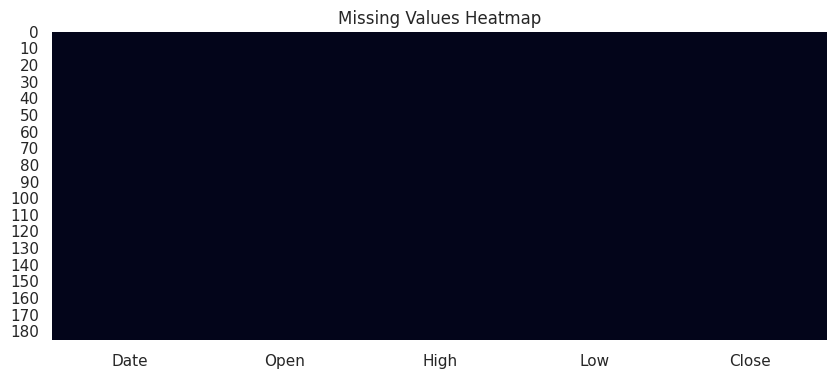

In [8]:
# Visualizing missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains monthly Yes Bank stock price information. It has five columns: Date, Open, High, Low and Close. There are no missing values in the provided data. The numerical columns are already in numeric format, while the Date column is initially stored as object type and needs conversion into datetime format. Since the target variable is Close price, this is a supervised regression problem. The dataset is time-based, so random shuffling must be avoided during final model splitting to reduce data leakage.

## ***2. Understanding Your Variables***

In [9]:
# Dataset columns
print('Columns in dataset:')
print(df.columns.tolist())

# Statistical summary
print('\nNumerical Summary:')
display(df.describe())

Columns in dataset:
['Date', 'Open', 'High', 'Low', 'Close']

Numerical Summary:


,Open,High,Low,Close
count,185.0000,185.0000,185.0000,185.0000
mean,105.5414,116.1043,94.9478,105.2047
std,98.8798,106.3335,91.2194,98.5832
min,10.0000,11.2400,5.5500,9.9800
25%,33.8000,36.1400,28.5100,33.4500
50%,62.9800,72.5500,58.0000,62.5400
75%,153.0000,169.1900,138.3500,153.3000
max,369.9500,404.0000,345.5000,367.9000


### Variables Description

- **Date**: Month and year of the stock record.
- **Open**: Stock price at the beginning of the month.
- **High**: Highest stock price recorded during the month.
- **Low**: Lowest stock price recorded during the month.
- **Close**: Stock price at the end of the month. This is the target variable for prediction.

### Check Unique Values for each variable.

In [10]:
# Unique values count for each column
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')
    print(df[col].unique()[:10])
    print('-' * 60)

Date: 185 unique values
['Jul-05' 'Aug-05' 'Sep-05' 'Oct-05' 'Nov-05' 'Dec-05' 'Jan-06' 'Feb-06'
 'Mar-06' 'Apr-06']
------------------------------------------------------------
Open: 183 unique values
[13.   12.58 13.48 13.2  13.35 13.49 13.68 15.5  16.2  20.56]
------------------------------------------------------------
High: 184 unique values
[14.   14.88 14.87 14.47 13.88 14.44 17.16 16.97 20.95 20.8 ]
------------------------------------------------------------
Low: 183 unique values
[11.25 12.55 12.27 12.4  12.88 13.   13.58 15.4  16.02 18.02]
------------------------------------------------------------
Close: 185 unique values
[12.46 13.42 13.3  12.99 13.41 13.71 15.33 16.12 20.08 19.49]
------------------------------------------------------------


## 3. ***Data Wrangling***

### Data Wrangling Code

In [11]:
# Data Wrangling and Feature Engineering
processed_df = df.copy()

# Remove duplicate rows if any
processed_df = processed_df.drop_duplicates().reset_index(drop=True)

# Convert Date column into datetime format. The dataset format is like Jul-05.
processed_df['Date'] = pd.to_datetime(processed_df['Date'], format='%b-%y')
processed_df = processed_df.sort_values('Date').reset_index(drop=True)

# Basic time features
processed_df['Year'] = processed_df['Date'].dt.year
processed_df['Month'] = processed_df['Date'].dt.month
processed_df['Quarter'] = processed_df['Date'].dt.quarter
processed_df['Month_Number'] = np.arange(1, len(processed_df) + 1)
processed_df['Year_Month'] = processed_df['Date'].dt.to_period('M').astype(str)

# Price movement and volatility features
processed_df['Price_Range'] = processed_df['High'] - processed_df['Low']
processed_df['Average_Price'] = (processed_df['Open'] + processed_df['High'] + processed_df['Low'] + processed_df['Close']) / 4
processed_df['Open_Close_Diff'] = processed_df['Close'] - processed_df['Open']
processed_df['Daily_Return_%'] = ((processed_df['Close'] - processed_df['Open']) / processed_df['Open']) * 100
processed_df['High_Low_%'] = ((processed_df['High'] - processed_df['Low']) / processed_df['Low']) * 100

# Lag features use previous month information and reduce leakage risk
processed_df['Close_Lag_1'] = processed_df['Close'].shift(1)
processed_df['Close_Lag_2'] = processed_df['Close'].shift(2)
processed_df['Open_Lag_1'] = processed_df['Open'].shift(1)
processed_df['Return_Lag_1'] = processed_df['Daily_Return_%'].shift(1)

# Rolling window features based on previous records
processed_df['MA_3'] = processed_df['Close'].rolling(window=3).mean()
processed_df['MA_6'] = processed_df['Close'].rolling(window=6).mean()
processed_df['MA_12'] = processed_df['Close'].rolling(window=12).mean()
processed_df['Rolling_Std_3'] = processed_df['Close'].rolling(window=3).std()
processed_df['Rolling_Std_6'] = processed_df['Close'].rolling(window=6).std()

# Trend label only for EDA/storytelling, not used as regression target
processed_df['Trend_Direction'] = np.where(processed_df['Open_Close_Diff'] >= 0, 'Positive/Up', 'Negative/Down')

# Fill rolling/lag missing values using backfill for early months
processed_df = processed_df.bfill().ffill()

print('Data wrangling completed successfully.')
display(processed_df.head())

Data wrangling completed successfully.


,Date,Open,High,Low,Close,Year,Month,Quarter,Month_Number,Year_Month,Price_Range,Average_Price,Open_Close_Diff,Daily_Return_%,High_Low_%,Close_Lag_1,Close_Lag_2,Open_Lag_1,Return_Lag_1,MA_3,MA_6,MA_12,Rolling_Std_3,Rolling_Std_6,Trend_Direction
0,2005-07-01,13.0000,14.0000,11.2500,12.4600,2005,7,3,1,2005-07,2.7500,12.6775,-0.5400,-4.1538,24.4444,12.4600,12.4600,13.0000,-4.1538,13.0600,13.2150,15.3300,0.5231,0.4366,Negative/Down
1,2005-08-01,12.5800,14.8800,12.5500,13.4200,2005,8,3,2,2005-08,2.3300,13.3575,0.8400,6.6773,18.5657,12.4600,12.4600,13.0000,-4.1538,13.0600,13.2150,15.3300,0.5231,0.4366,Positive/Up
2,2005-09-01,13.4800,14.8700,12.2700,13.3000,2005,9,3,3,2005-09,2.6000,13.4800,-0.1800,-1.3353,21.1899,13.4200,12.4600,12.5800,6.6773,13.0600,13.2150,15.3300,0.5231,0.4366,Negative/Down
3,2005-10-01,13.2000,14.4700,12.4000,12.9900,2005,10,4,4,2005-10,2.0700,13.2650,-0.2100,-1.5909,16.6935,13.3000,13.4200,13.4800,-1.3353,13.2367,13.2150,15.3300,0.2219,0.4366,Negative/Down
4,2005-11-01,13.3500,13.8800,12.8800,13.4100,2005,11,4,5,2005-11,1.0000,13.3800,0.0600,0.4494,7.7640,12.9900,13.3000,13.2000,-1.5909,13.2333,13.2150,15.3300,0.2178,0.4366,Positive/Up


### What all manipulations have you done and insights you found?

The Date column was converted into datetime format and the dataset was sorted chronologically. New time-based features such as Year, Month, Quarter and Month Number were created. Price movement features such as Price Range, Average Price, Open-Close Difference, Daily Return Percentage and High-Low Percentage were added to capture volatility and monthly performance. Lag features and moving averages were also created because stock prices are time-dependent and previous month behavior can help predict the current closing price. These manipulations make the dataset more useful for both EDA and machine learning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1: Closing Price Trend Over Time

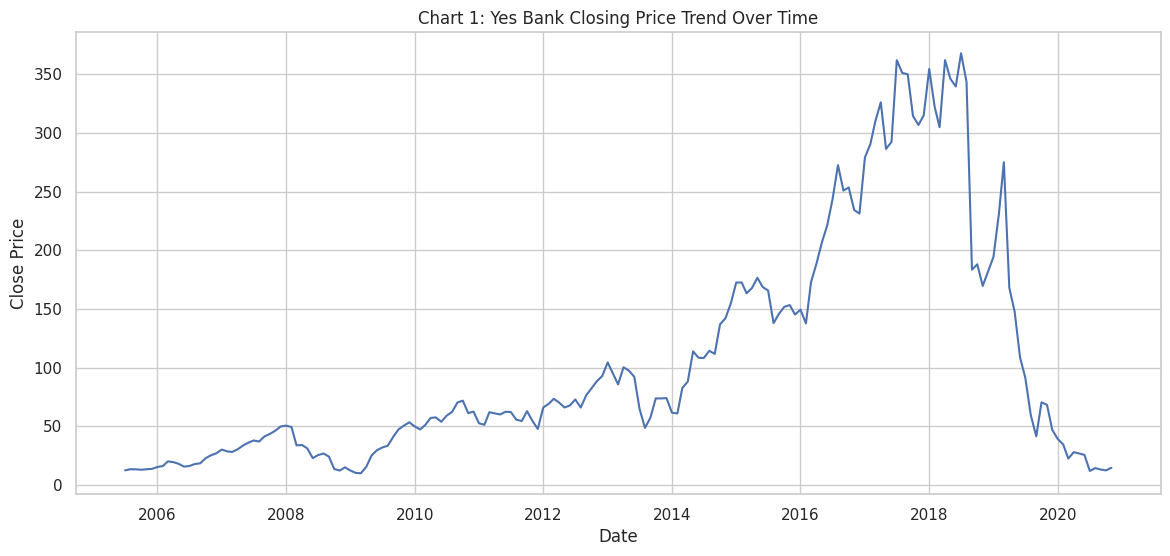

In [12]:
# Chart - 1 visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=processed_df, x='Date', y='Close')
plt.title('Chart 1: Yes Bank Closing Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
A line chart is best for showing stock price movement over time.

##### 2. What is/are the insight(s) found from the chart?
The closing price shows strong trend changes across years, meaning the stock did not remain stable throughout the period.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This helps analysts identify growth and decline phases. Sudden decline periods indicate risk and negative business sentiment.

#### Chart - 2: Open, High, Low and Close Trend

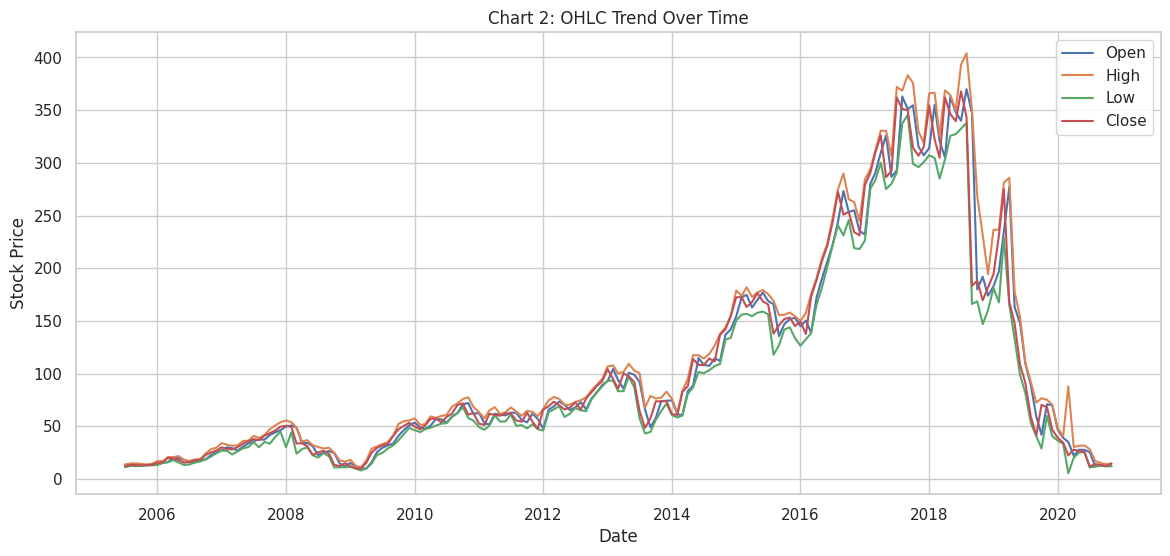

In [13]:
# Chart - 2 visualization
plt.figure(figsize=(14, 6))
for col in ['Open', 'High', 'Low', 'Close']:
    sns.lineplot(data=processed_df, x='Date', y=col, label=col)
plt.title('Chart 2: OHLC Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
A multi-line chart compares all stock price components together.

##### 2. What is/are the insight(s) found from the chart?
Open, High, Low and Close generally move together, showing strong relationship among OHLC variables.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This is positive for modeling because related features can help predict the closing price.

#### Chart - 3: Distribution of Closing Price

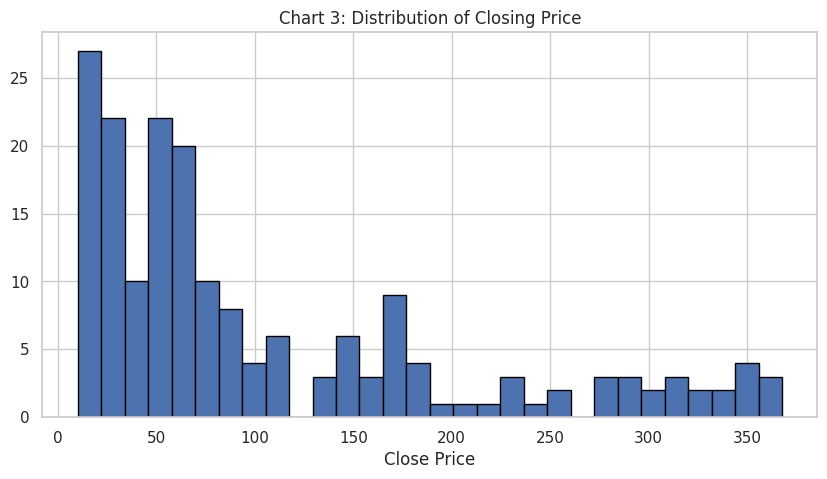

In [14]:
# Chart - 3 visualization
plt.figure(figsize=(10, 5))
plt.hist(processed_df['Close'], bins=30, edgecolor='black')
plt.title('Chart 3: Distribution of Closing Price')
plt.xlabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
A histogram shows the spread and frequency of closing price values.

##### 2. What is/are the insight(s) found from the chart?
The closing price is not normally distributed and has higher values in fewer months.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
Non-normal distribution suggests scaling or transformation may help some models.

#### Chart - 4: Boxplot of Closing Price

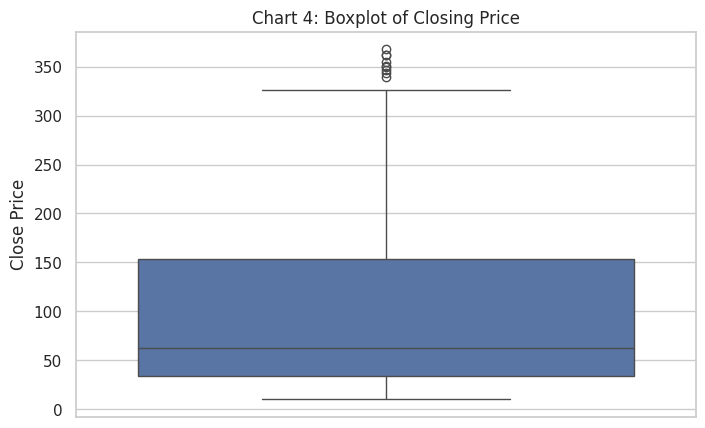

In [15]:
# Chart - 4 visualization
plt.figure(figsize=(8, 5))
sns.boxplot(y=processed_df['Close'], color='C0')
plt.title('Chart 4: Boxplot of Closing Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
A boxplot helps detect outliers and spread in closing price.

##### 2. What is/are the insight(s) found from the chart?
Some high closing price values behave like outliers compared to the majority of records.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
Outlier awareness is important because extreme prices can influence error-sensitive models.

#### Chart - 5: Yearly Average Closing Price

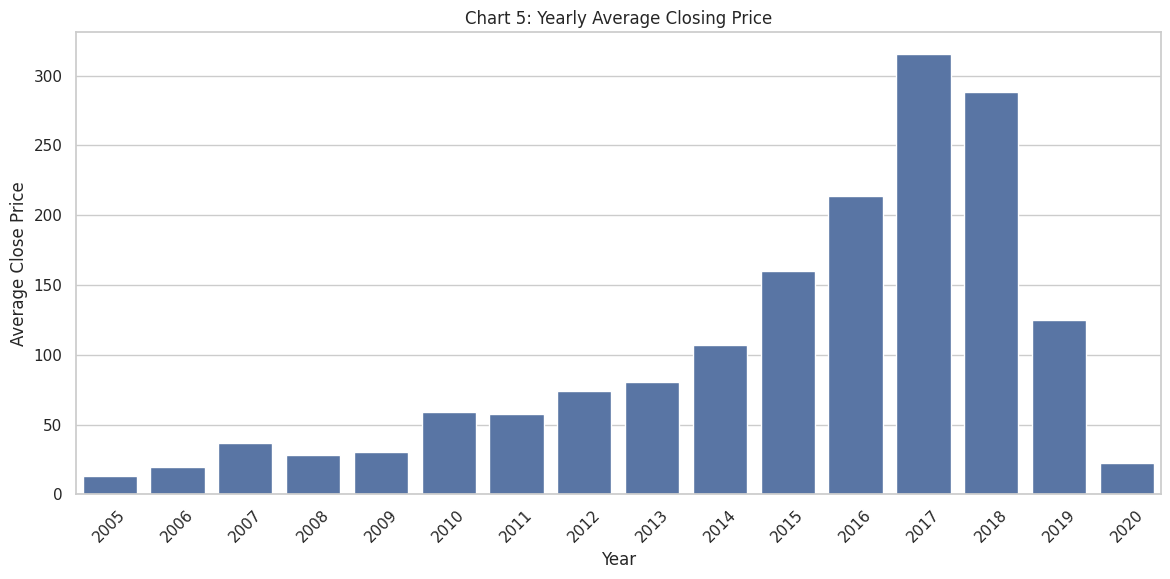

In [16]:
# Chart - 5 visualization
yearly_close = processed_df.groupby('Year')['Close'].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(data=yearly_close, x='Year', y='Close', color='C0')
plt.xticks(rotation=45)
plt.title('Chart 5: Yearly Average Closing Price')
plt.ylabel('Average Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart compares average closing price across years clearly.

##### 2. What is/are the insight(s) found from the chart?
Some years show much higher average close price than earlier years, indicating changing market valuation.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This helps investors understand which years were strong or weak for the stock.

#### Chart - 6: Monthly Average Closing Price

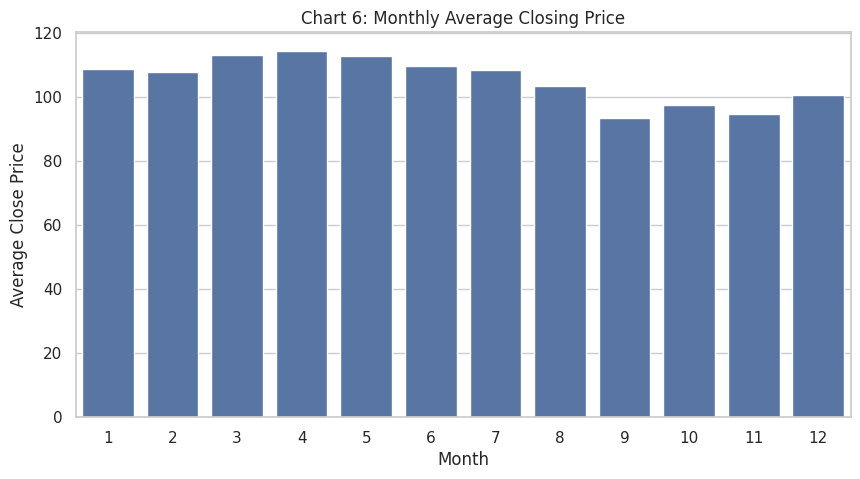

In [17]:
# Chart - 6 visualization
monthly_close = processed_df.groupby('Month')['Close'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_close, x='Month', y='Close', color='C0')
plt.title('Chart 6: Monthly Average Closing Price')
plt.ylabel('Average Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
This chart checks whether some months have higher average closing values.

##### 2. What is/are the insight(s) found from the chart?
Month-wise variation exists, but the dataset is more trend-driven than seasonality-driven.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This insight helps decide that time trend and lag features are more important than month alone.

#### Chart - 7: Price Range Over Time

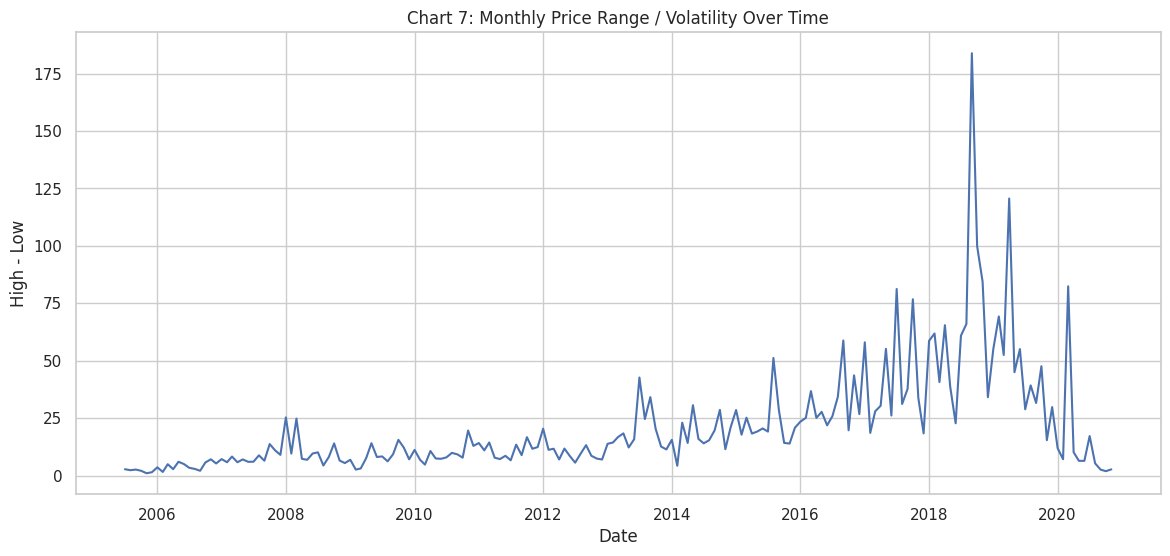

In [18]:
# Chart - 7 visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=processed_df, x='Date', y='Price_Range')
plt.title('Chart 7: Monthly Price Range / Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('High - Low')
plt.show()

##### 1. Why did you pick the specific chart?
A line chart shows how volatility changes over time.

##### 2. What is/are the insight(s) found from the chart?
Price range increases during uncertain periods, showing higher volatility.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
High volatility can be risky for investors and important for prediction uncertainty.

#### Chart - 8: Daily Return Percentage Distribution

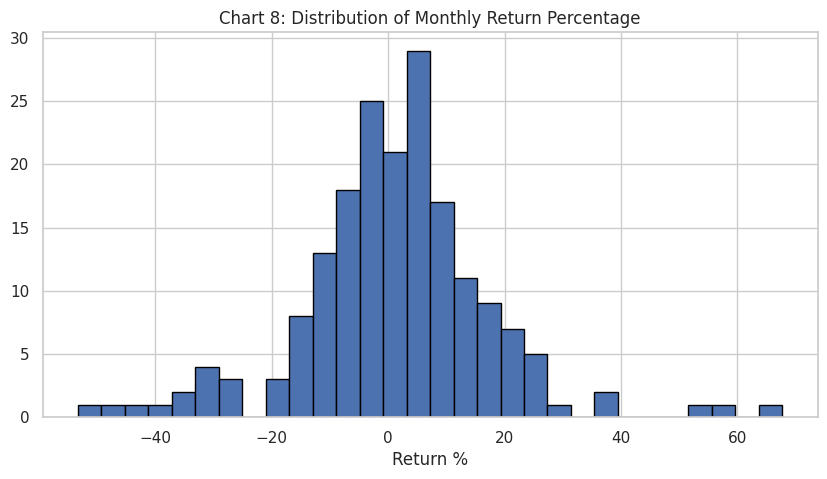

In [19]:
# Chart - 8 visualization
plt.figure(figsize=(10, 5))
plt.hist(processed_df['Daily_Return_%'], bins=30, edgecolor='black')
plt.title('Chart 8: Distribution of Monthly Return Percentage')
plt.xlabel('Return %')
plt.show()

##### 1. Why did you pick the specific chart?
A return distribution shows how frequently the stock gained or lost in a month.

##### 2. What is/are the insight(s) found from the chart?
Returns are spread around positive and negative values, showing both profit and loss months.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This helps understand risk because frequent negative returns may indicate unstable performance.

#### Chart - 9: Open vs Close Scatter Plot

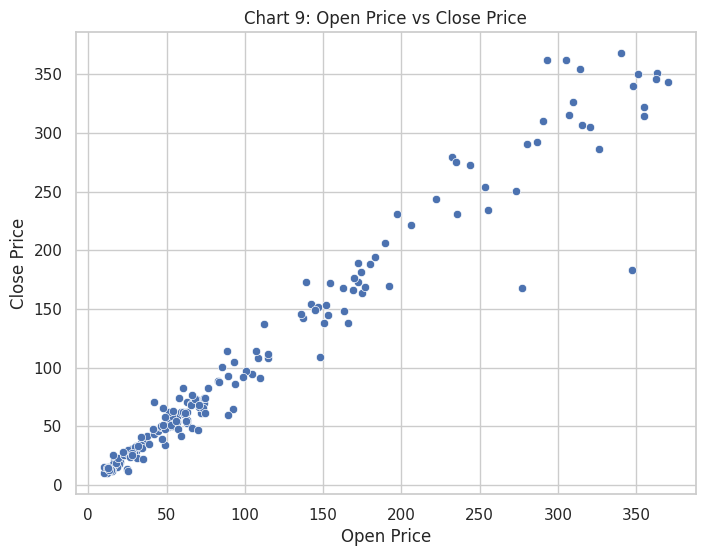

In [20]:
# Chart - 9 visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=processed_df, x='Open', y='Close')
plt.title('Chart 9: Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
A scatter plot shows the relationship between opening and closing price.

##### 2. What is/are the insight(s) found from the chart?
Open and Close have a strong positive linear relationship.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This is useful because Open price can be a strong predictor of Close price.

#### Chart - 10: High vs Close Scatter Plot

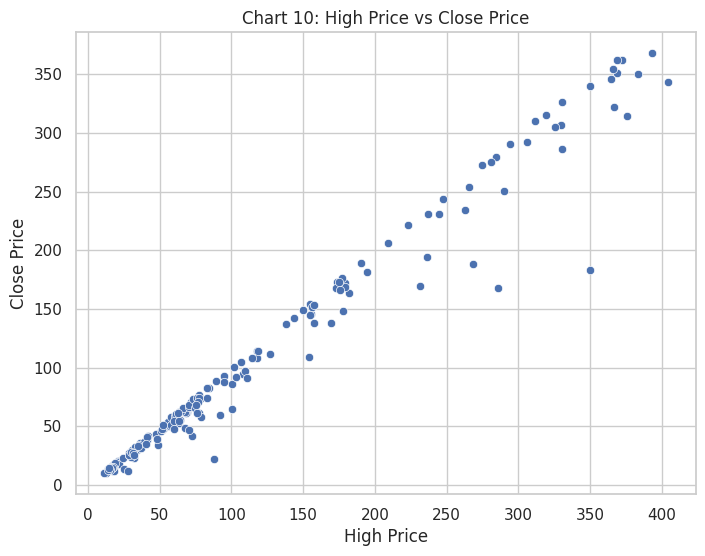

In [21]:
# Chart - 10 visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=processed_df, x='High', y='Close')
plt.title('Chart 10: High Price vs Close Price')
plt.xlabel('High Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
This scatter plot checks how the highest monthly price relates to closing price.

##### 2. What is/are the insight(s) found from the chart?
High price is strongly related to Close price.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This gives positive modeling impact because High contains useful price-level information.

#### Chart - 11: Low vs Close Scatter Plot

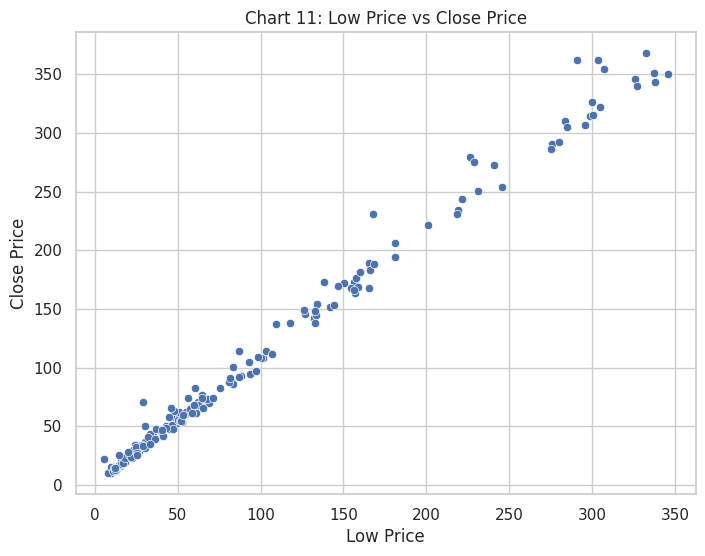

In [22]:
# Chart - 11 visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=processed_df, x='Low', y='Close')
plt.title('Chart 11: Low Price vs Close Price')
plt.xlabel('Low Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
This chart checks relation between lowest monthly price and closing price.

##### 2. What is/are the insight(s) found from the chart?
Low price also has a strong positive relationship with Close price.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This helps model understand the lower support level of the stock.

#### Chart - 12: Average Price vs Close

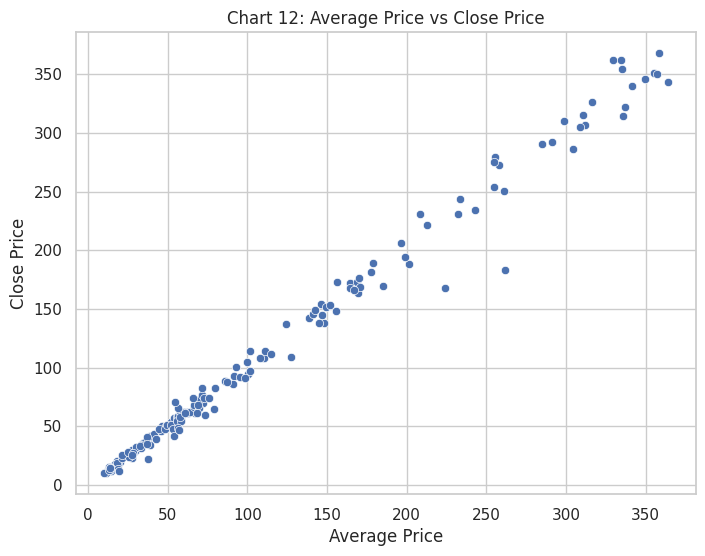

In [23]:
# Chart - 12 visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=processed_df, x='Average_Price', y='Close')
plt.title('Chart 12: Average Price vs Close Price')
plt.xlabel('Average Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
Average price combines OHLC information and is compared with the target.

##### 2. What is/are the insight(s) found from the chart?
Average Price is highly aligned with Close price.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This engineered feature may improve model performance because it summarizes monthly price behavior.

#### Chart - 13: Moving Average Trend

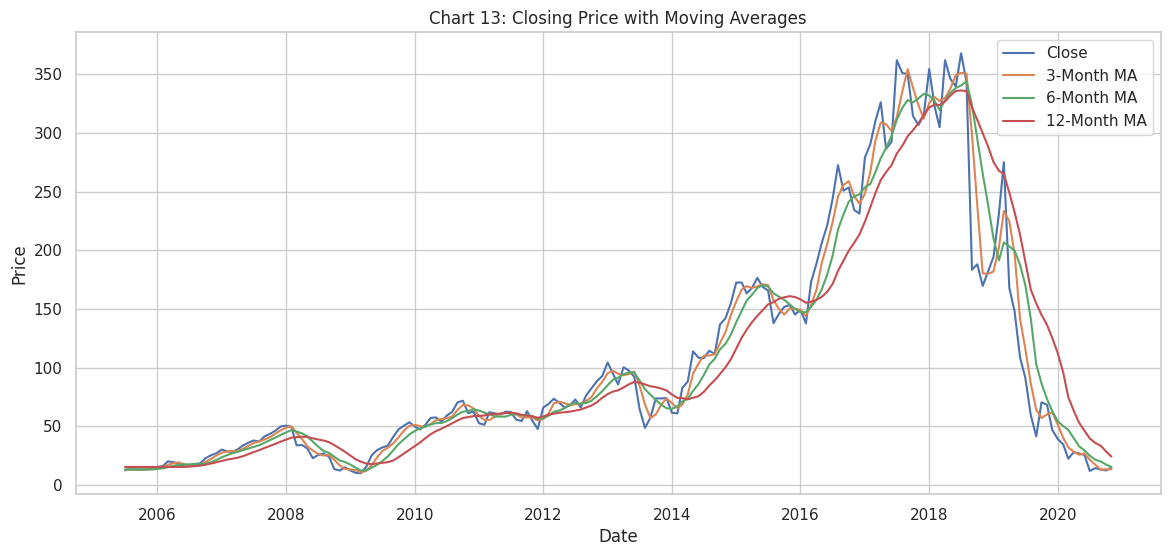

In [24]:
# Chart - 13 visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=processed_df, x='Date', y='Close', label='Close')
sns.lineplot(data=processed_df, x='Date', y='MA_3', label='3-Month MA')
sns.lineplot(data=processed_df, x='Date', y='MA_6', label='6-Month MA')
sns.lineplot(data=processed_df, x='Date', y='MA_12', label='12-Month MA')
plt.title('Chart 13: Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
Moving average lines smooth short-term noise and show trend direction.

##### 2. What is/are the insight(s) found from the chart?
Moving averages follow the closing price and show long-term trend more clearly.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This helps investors and models understand trend rather than only monthly fluctuations.

#### Chart - 14: Correlation Heatmap

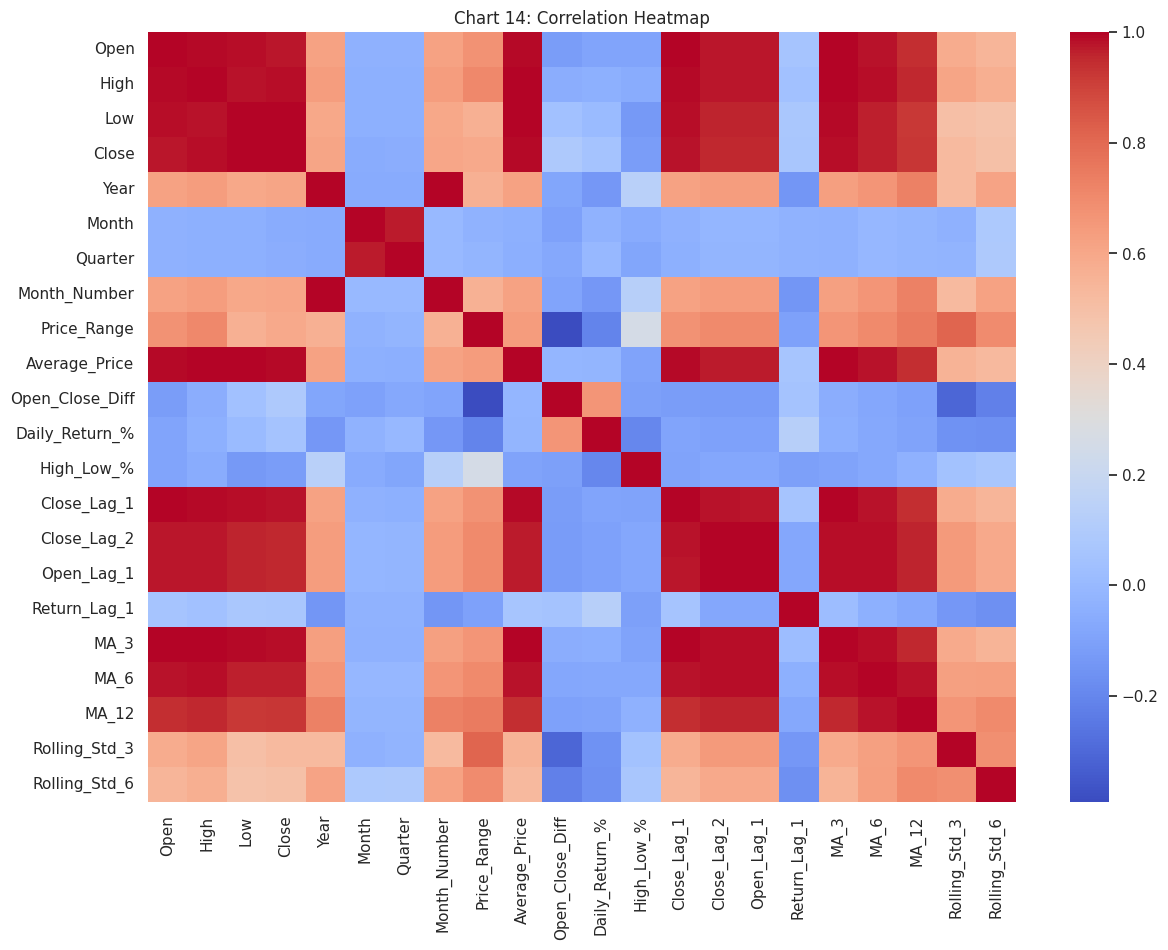

In [25]:
# Chart - 14 visualization
numeric_cols = processed_df.select_dtypes(include=np.number).columns
plt.figure(figsize=(14, 10))
sns.heatmap(processed_df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Chart 14: Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap is used to understand correlation among numerical variables.

##### 2. What is/are the insight(s) found from the chart?
OHLC and engineered price features have strong correlation with Close.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This supports feature selection and warns about multicollinearity in linear models.

#### Chart - 15: Pair Plot of Important Features

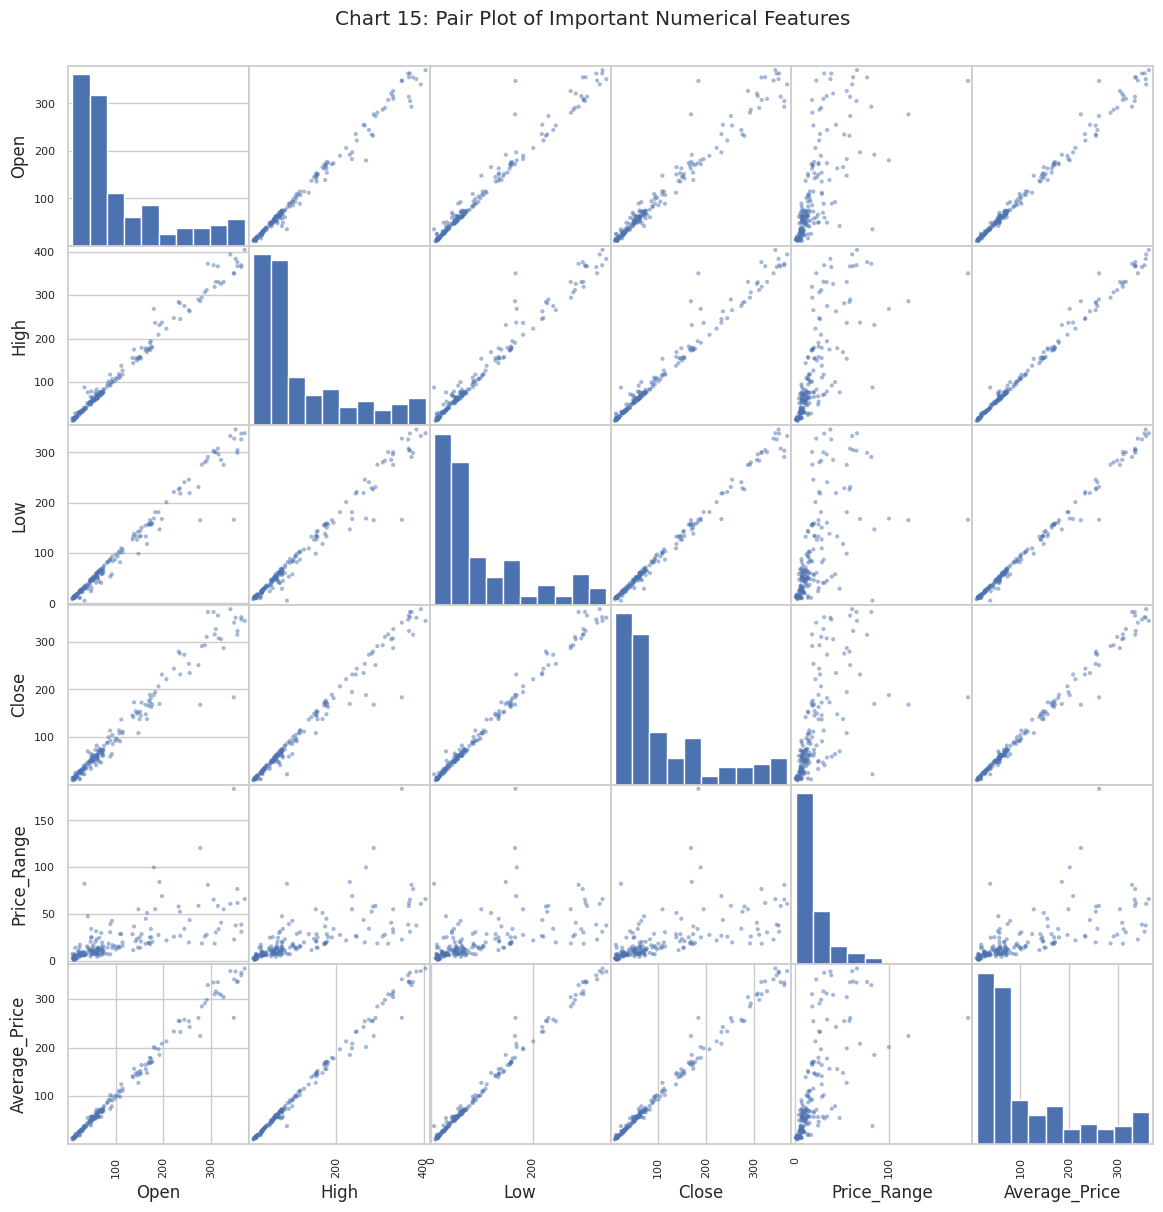

In [26]:
# Chart - 15 visualization
pair_cols = ['Open', 'High', 'Low', 'Close', 'Price_Range', 'Average_Price']
pd.plotting.scatter_matrix(processed_df[pair_cols], figsize=(14, 14), diagonal='hist')
plt.suptitle('Chart 15: Pair Plot of Important Numerical Features', y=0.92)
plt.show()

##### 1. Why did you pick the specific chart?
Pair plot gives a quick multivariate view of important numerical features.

##### 2. What is/are the insight(s) found from the chart?
Price-level features show strong linear patterns with Close price.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This confirms that regression models are suitable for the project.

#### Chart - 16: Trend Direction Count

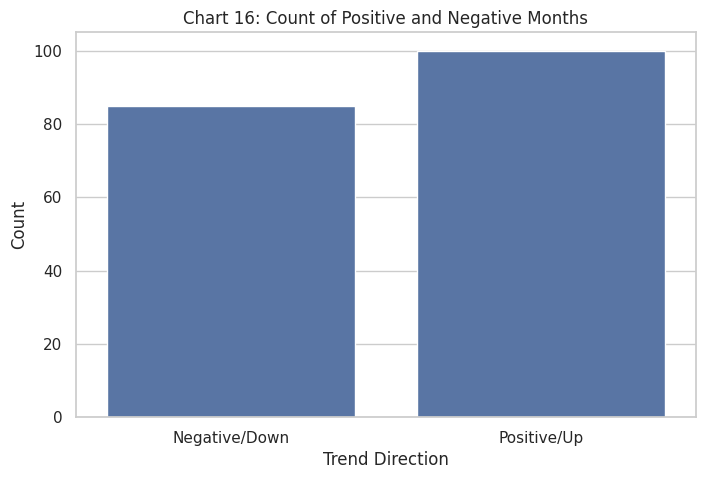

In [27]:
# Chart - 16 visualization
plt.figure(figsize=(8, 5))
sns.countplot(data=processed_df, x='Trend_Direction', color='C0')
plt.title('Chart 16: Count of Positive and Negative Months')
plt.xlabel('Trend Direction')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?
A count plot shows how many months ended positive or negative.

##### 2. What is/are the insight(s) found from the chart?
The stock has both positive and negative closing movement months.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This is useful for risk understanding because negative months represent possible loss periods.

#### Chart - 17: Rolling Volatility

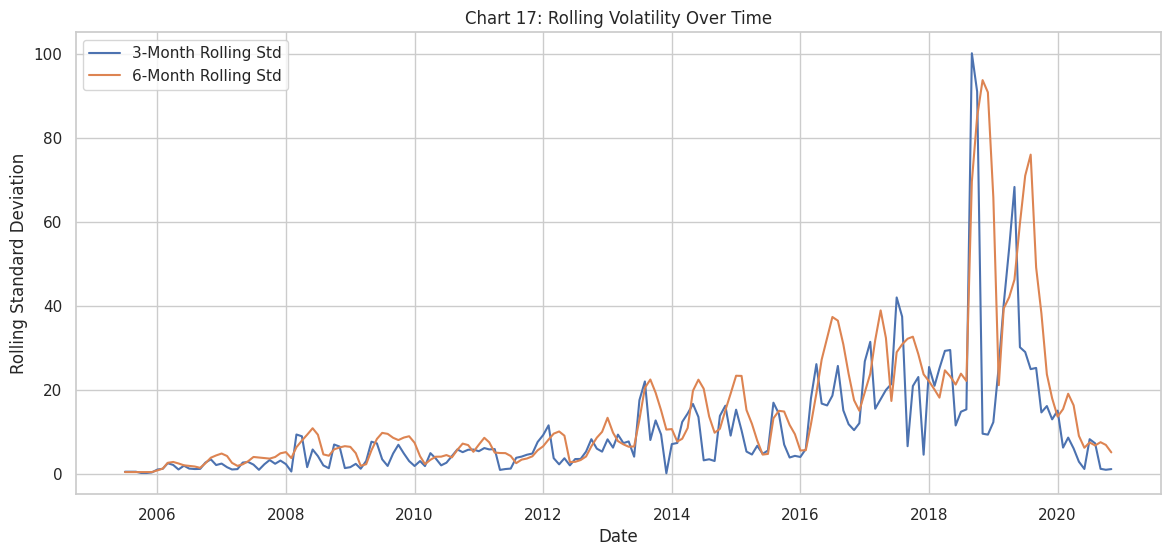

In [28]:
# Chart - 17 visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=processed_df, x='Date', y='Rolling_Std_3', label='3-Month Rolling Std')
sns.lineplot(data=processed_df, x='Date', y='Rolling_Std_6', label='6-Month Rolling Std')
plt.title('Chart 17: Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Rolling Standard Deviation')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
Rolling standard deviation is used to study changing volatility.

##### 2. What is/are the insight(s) found from the chart?
Volatility rises sharply during unstable periods.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
High volatility creates negative business impact because predictions become less certain.

#### Chart - 18: Open-Close Difference Over Time

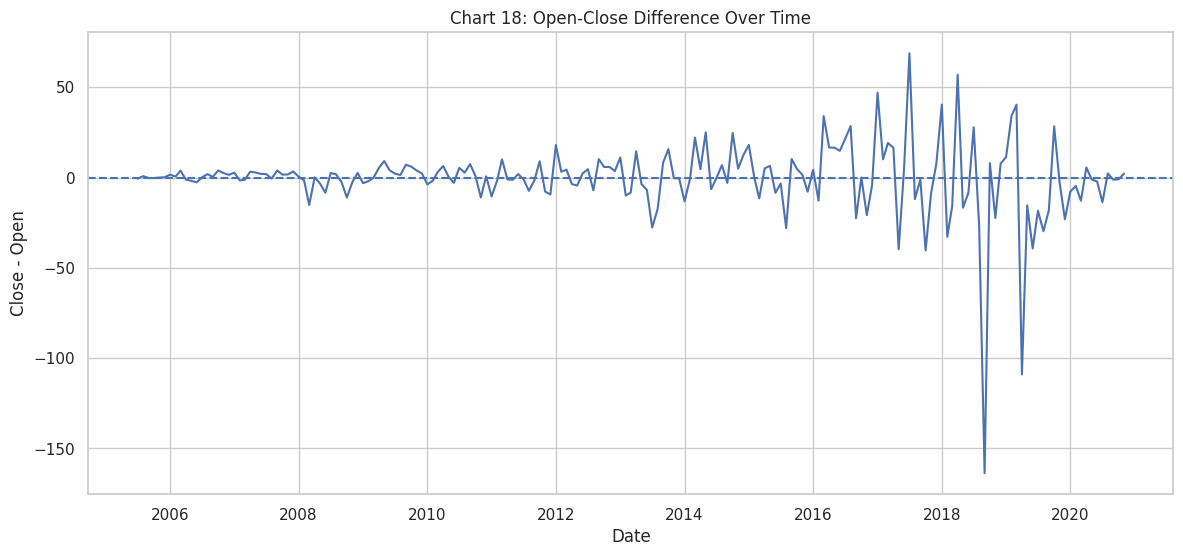

In [29]:
# Chart - 18 visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=processed_df, x='Date', y='Open_Close_Diff')
plt.axhline(0, linestyle='--')
plt.title('Chart 18: Open-Close Difference Over Time')
plt.xlabel('Date')
plt.ylabel('Close - Open')
plt.show()

##### 1. Why did you pick the specific chart?
This chart shows whether the stock closed above or below its opening price.

##### 2. What is/are the insight(s) found from the chart?
The difference moves above and below zero, showing mixed monthly sentiment.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
Positive difference supports bullish behavior, while negative difference indicates weak monthly sentiment.

#### Chart - 19: Quarter-wise Closing Price

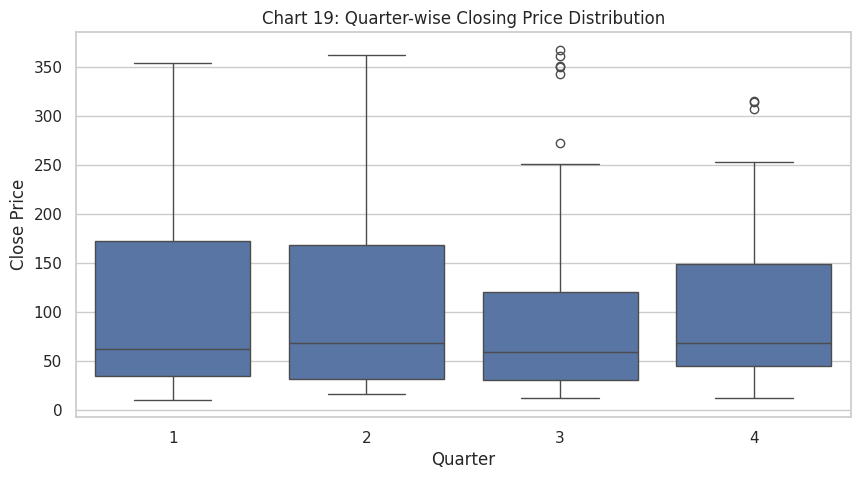

In [30]:
# Chart - 19 visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=processed_df, x='Quarter', y='Close', color='C0')
plt.title('Chart 19: Quarter-wise Closing Price Distribution')
plt.xlabel('Quarter')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?
A boxplot compares closing price distribution across quarters.

##### 2. What is/are the insight(s) found from the chart?
Quarter-wise differences are visible but not as strong as long-term trend.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This suggests quarter can be a secondary feature, while price history remains more important.

#### Chart - 20: Feature Relationship with Target

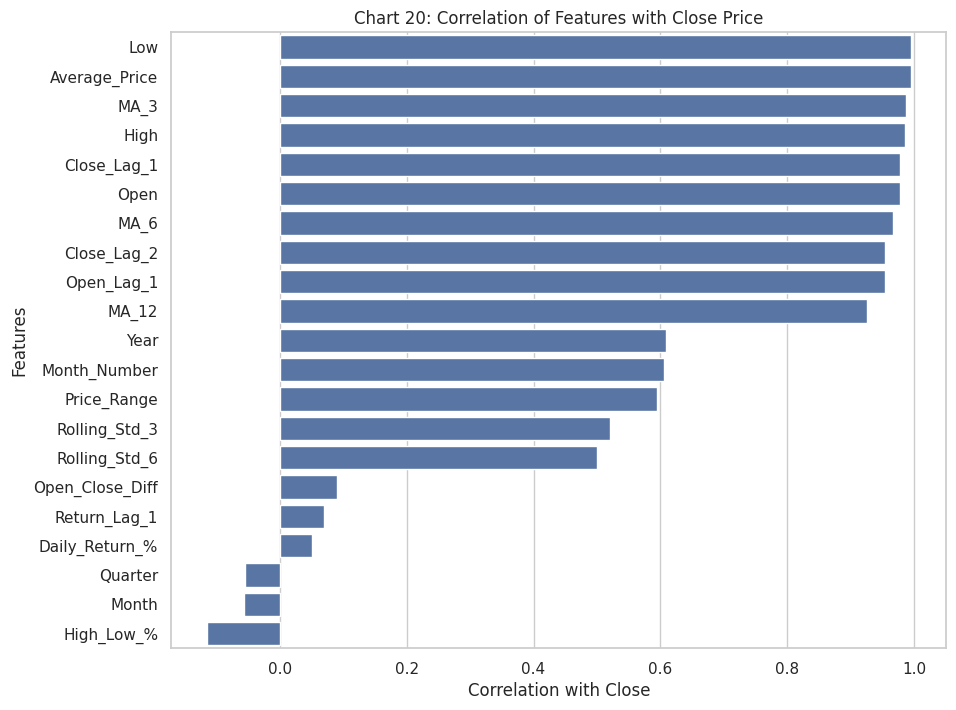

In [31]:
# Chart - 20 visualization
target_corr = processed_df.select_dtypes(include=np.number).corr()['Close'].sort_values(ascending=False).drop('Close')
plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, color='C0')
plt.title('Chart 20: Correlation of Features with Close Price')
plt.xlabel('Correlation with Close')
plt.ylabel('Features')
plt.show()

##### 1. Why did you pick the specific chart?
This bar chart ranks features based on correlation with the target.

##### 2. What is/are the insight(s) found from the chart?
Open, High, Low, Average Price and moving averages are strongly related to Close.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.
This helps select useful features and improves model interpretability.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about each statement.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
**Null Hypothesis H0:** The average monthly return percentage is equal to 0.

**Alternate Hypothesis H1:** The average monthly return percentage is significantly different from 0.

#### 2. Perform an appropriate statistical test.

In [32]:
# One-sample t-test for average monthly return percentage
returns = processed_df['Daily_Return_%'].dropna()
t_stat_1, p_value_1 = stats.ttest_1samp(returns, popmean=0)
print(f'T-statistic: {t_stat_1:.4f}')
print(f'P-value: {p_value_1:.4f}')
alpha = 0.05
if p_value_1 < alpha:
    print('Reject H0: Average monthly return is significantly different from 0.')
else:
    print('Fail to Reject H0: Average monthly return is not significantly different from 0.')

T-statistic: 0.8598
P-value: 0.3910
Fail to Reject H0: Average monthly return is not significantly different from 0.


##### Which statistical test have you done to obtain P-Value?
A one-sample t-test was used.

##### Why did you choose the specific statistical test?
This test is suitable because we compare the mean of one numerical sample against a known value, which is 0% return.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
**H0:** The average closing price is the same in high-volatility and low-volatility months.

**H1:** The average closing price is different in high-volatility and low-volatility months.

#### 2. Perform an appropriate statistical test.

In [33]:
# Independent t-test between high volatility and low volatility months
median_range = processed_df['Price_Range'].median()
high_vol_close = processed_df.loc[processed_df['Price_Range'] > median_range, 'Close']
low_vol_close = processed_df.loc[processed_df['Price_Range'] <= median_range, 'Close']

t_stat_2, p_value_2 = stats.ttest_ind(high_vol_close, low_vol_close, equal_var=False)
print(f'T-statistic: {t_stat_2:.4f}')
print(f'P-value: {p_value_2:.4f}')
if p_value_2 < alpha:
    print('Reject H0: Average closing price differs between high and low volatility months.')
else:
    print('Fail to Reject H0: No significant difference in average closing price.')

T-statistic: 11.5118
P-value: 0.0000
Reject H0: Average closing price differs between high and low volatility months.


##### Which statistical test have you done to obtain P-Value?
Welch independent two-sample t-test was used.

##### Why did you choose the specific statistical test?
It compares the mean closing price of two independent groups: high-volatility months and low-volatility months.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
**H0:** Open price and Close price have no significant linear relationship.

**H1:** Open price and Close price have a significant linear relationship.

#### 2. Perform an appropriate statistical test.

In [34]:
# Pearson correlation test between Open and Close prices
corr_value, p_value_3 = stats.pearsonr(processed_df['Open'], processed_df['Close'])
print(f'Pearson Correlation: {corr_value:.4f}')
print(f'P-value: {p_value_3:.4f}')
if p_value_3 < alpha:
    print('Reject H0: Open and Close prices have a significant linear relationship.')
else:
    print('Fail to Reject H0: No significant linear relationship found.')

Pearson Correlation: 0.9780
P-value: 0.0000
Reject H0: Open and Close prices have a significant linear relationship.


##### Which statistical test have you done to obtain P-Value?
Pearson correlation significance test was used.

##### Why did you choose the specific statistical test?
It is suitable because both Open and Close are continuous numerical variables and we want to test their linear relationship.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [35]:
# Final missing value check after feature engineering
print(processed_df.isnull().sum())

Date               0
Open               0
High               0
Low                0
Close              0
Year               0
Month              0
Quarter            0
Month_Number       0
Year_Month         0
Price_Range        0
Average_Price      0
Open_Close_Diff    0
Daily_Return_%     0
High_Low_%         0
Close_Lag_1        0
Close_Lag_2        0
Open_Lag_1         0
Return_Lag_1       0
MA_3               0
MA_6               0
MA_12              0
Rolling_Std_3      0
Rolling_Std_6      0
Trend_Direction    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?
The original dataset had no missing values. Lag and rolling features created initial missing values, which were handled using backfill and forward fill because the dataset is time-series based and early records need nearby historical values for model execution.

### 2. Handling Outliers

In [36]:
# IQR based outlier capping for selected numerical features
model_df = processed_df.copy()
cap_cols = ['Open', 'High', 'Low', 'Close', 'Price_Range', 'Daily_Return_%', 'High_Low_%']
for col in cap_cols:
    q1 = model_df[col].quantile(0.25)
    q3 = model_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    model_df[col] = model_df[col].clip(lower, upper)
print('Outlier capping completed for selected numerical columns.')

Outlier capping completed for selected numerical columns.


##### What all outlier treatment techniques have you used and why did you use those techniques?
IQR-based capping was used instead of deleting rows because the dataset is small and time-series records should not be removed unnecessarily. Capping controls extreme values while preserving data continuity.

### 3. Categorical Encoding

In [37]:
# Encode Trend_Direction only for optional model usage
model_df['Trend_Direction_Encoded'] = model_df['Trend_Direction'].map({'Negative/Down': 0, 'Positive/Up': 1})
print(model_df[['Trend_Direction', 'Trend_Direction_Encoded']].head())

  Trend_Direction  Trend_Direction_Encoded
0   Negative/Down                        0
1     Positive/Up                        1
2   Negative/Down                        0
3   Negative/Down                        0
4     Positive/Up                        1


#### What all categorical encoding techniques have you used & why did you use those techniques?
The dataset is mainly numerical. Trend Direction was encoded using binary label encoding because it has only two categories: Positive/Up and Negative/Down.

### 4. Textual Data Preprocessing | (It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

This project is not a textual/NLP dataset, so textual preprocessing steps such as lower casing, tokenization, stopword removal and vectorization are not required.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [38]:
# Prepare features and target
feature_cols = [
    'Open', 'High', 'Low', 'Year', 'Month', 'Quarter', 'Month_Number',
    'Price_Range', 'Average_Price', 'Open_Close_Diff', 'Daily_Return_%', 'High_Low_%',
    'Close_Lag_1', 'Close_Lag_2', 'Open_Lag_1', 'Return_Lag_1',
    'MA_3', 'MA_6', 'MA_12', 'Rolling_Std_3', 'Rolling_Std_6', 'Trend_Direction_Encoded'
]
X = model_df[feature_cols]
y = model_df['Close']
print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (185, 22)
Target shape: (185,)


#### 2. Feature Selection

In [39]:
# Correlation based feature importance with target
feature_target_corr = pd.concat([X, y], axis=1).corr()['Close'].drop('Close').abs().sort_values(ascending=False)
display(feature_target_corr.to_frame('Absolute Correlation with Close'))

,Absolute Correlation with Close
Low,0.9966
Average_Price,0.9945
MA_3,0.9881
High,0.9854
Open,0.9815
Close_Lag_1,0.9796
MA_6,0.9673
Close_Lag_2,0.9563
Open_Lag_1,0.9560
MA_12,0.9266


##### What all feature selection methods have you used  and why?
Correlation analysis and model-based feature importance were used. Correlation helps identify variables that strongly move with Close price, while model-based importance helps understand practical predictive contribution.

##### Which all features you found important and why?
Open, High, Low, Average Price, lag close values and moving averages are important because they directly represent price level, trend and recent market behavior. These variables strongly explain the closing price.

### 5. Data Transformation

In [40]:
# Check skewness to understand transformation need
skewness = X.skew().sort_values(ascending=False)
display(skewness.to_frame('Skewness'))

,Skewness
Rolling_Std_3,3.6768
Rolling_Std_6,2.5523
Open_Lag_1,1.2658
Close_Lag_2,1.2644
Close_Lag_1,1.2643
Average_Price,1.2463
Low,1.2276
MA_3,1.2235
High,1.1988
Open,1.1937


#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?
Some numerical variables are skewed because stock prices increased and declined sharply across years. For linear model pipeline, StandardScaler is used. Power transformation can be considered, but tree models do not require strict transformation.

### 6. Data Scaling

In [41]:
# Scaling will be applied inside model pipelines where required
numeric_features = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features)]
)
print('Preprocessing pipeline created successfully.')

Preprocessing pipeline created successfully.


##### Which method have you used to scale you data and why?
StandardScaler was used for Linear Regression because linear models are sensitive to feature scale. Tree-based models like Random Forest and Gradient Boosting do not strictly need scaling.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?
Dimensionality reduction is not required because the dataset has limited features and interpretability is important. Removing dimensions using PCA may reduce business explainability.

In [42]:
# No dimensionality reduction applied
print('Dimensionality reduction not applied because feature count is manageable and interpretability is required.')

Dimensionality reduction not applied because feature count is manageable and interpretability is required.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)
No dimensionality reduction technique was used.

### 8. Data Splitting

In [43]:
# Time-aware train-test split without shuffling
split_index = int(len(model_df) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 148
Testing rows: 37


##### What data splitting ratio have you used and why?
An 80:20 time-aware split was used. The first 80% records were used for training and the latest 20% records were used for testing. This is suitable for stock data because future values should not be used to train past predictions.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.
This is a regression problem, not a classification problem. Therefore class imbalance is not applicable.

In [44]:
print('Imbalanced dataset handling is not required for this regression project.')

Imbalanced dataset handling is not required for this regression project.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)
No imbalance handling technique was used because the target variable is continuous.

## ***7. ML Model Implementation***

In [45]:
# Helper function to evaluate regression models
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    """Fit a model and return common regression metrics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = {
        'Model': model_name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2 Score': r2_score(y_test, y_pred)
    }
    return metrics, y_pred

model_results = []
predictions = {}

### ML Model - 1

In [46]:
# ML Model - 1: Linear Regression
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_metrics, linear_pred = evaluate_regression_model(
    linear_model, X_train, X_test, y_train, y_test, 'Linear Regression'
)
model_results.append(linear_metrics)
predictions['Linear Regression'] = linear_pred
pd.DataFrame([linear_metrics])

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,13.1832,934.7684,30.5740,0.9387


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.
Linear Regression was used as a baseline regression model. It tries to learn a linear relationship between stock price features and closing price. It is easy to interpret and useful for comparing with advanced models.

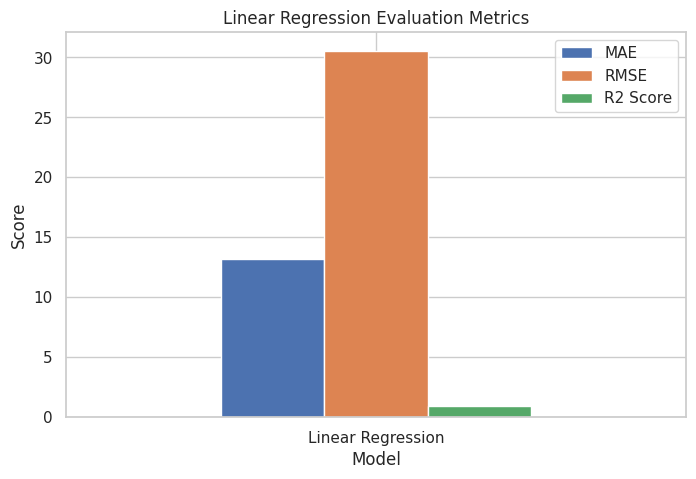

In [47]:
# Evaluation metric score chart for Linear Regression
pd.DataFrame([linear_metrics]).set_index('Model')[['MAE', 'RMSE', 'R2 Score']].plot(kind='bar', figsize=(8, 5))
plt.title('Linear Regression Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [48]:
# Ridge Regression tuning as regularized linear model
tscv = TimeSeriesSplit(n_splits=5)
ridge_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', Ridge())])
ridge_params = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=tscv, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print('Best Ridge Parameters:', ridge_grid.best_params_)
ridge_metrics, ridge_pred = evaluate_regression_model(ridge_grid.best_estimator_, X_train, X_test, y_train, y_test, 'Tuned Ridge Regression')
pd.DataFrame([ridge_metrics])

Best Ridge Parameters: {'model__alpha': 0.01}


,Model,MAE,MSE,RMSE,R2 Score
0,Tuned Ridge Regression,8.6544,319.6495,17.8787,0.9790


##### Which hyperparameter optimization technique have you used and why?
GridSearchCV with TimeSeriesSplit was used because it tests multiple alpha values while respecting chronological order.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
The tuned Ridge model is compared with baseline Linear Regression using RMSE and R2. If Ridge reduces RMSE or improves R2, it is considered an improvement.

### ML Model - 2

In [49]:
# ML Model - 2: Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=200, max_depth=8)
rf_metrics, rf_pred = evaluate_regression_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest Regressor')
model_results.append(rf_metrics)
predictions['Random Forest Regressor'] = rf_pred
pd.DataFrame([rf_metrics])

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,22.6133,971.5532,31.1697,0.9363


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.
Random Forest Regressor is an ensemble model that builds many decision trees and averages their predictions. It can capture non-linear relationships and is less sensitive to outliers than simple linear models.

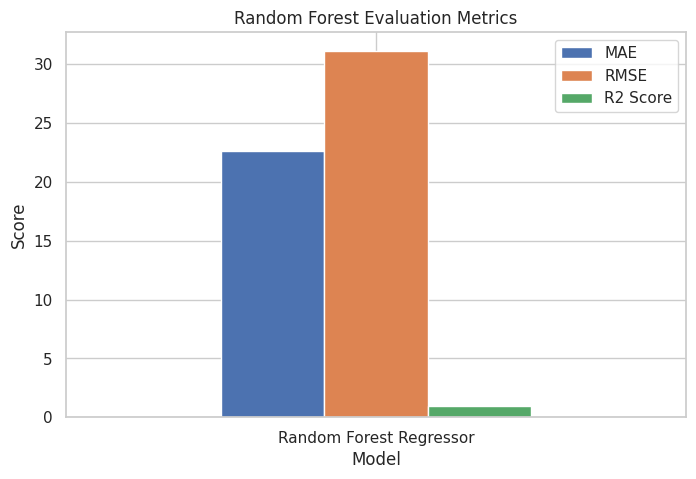

In [50]:
# Evaluation metric score chart for Random Forest
pd.DataFrame([rf_metrics]).set_index('Model')[['MAE', 'RMSE', 'R2 Score']].plot(kind='bar', figsize=(8, 5))
plt.title('Random Forest Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [51]:
# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [100],
    'max_depth': [4, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)
rf_grid.fit(X_train, y_train)
print('Best Random Forest Parameters:', rf_grid.best_params_)
rf_tuned_metrics, rf_tuned_pred = evaluate_regression_model(rf_grid.best_estimator_, X_train, X_test, y_train, y_test, 'Tuned Random Forest')
model_results.append(rf_tuned_metrics)
predictions['Tuned Random Forest'] = rf_tuned_pred
pd.DataFrame([rf_tuned_metrics])

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


,Model,MAE,MSE,RMSE,R2 Score
0,Tuned Random Forest,21.5677,900.5929,30.0099,0.9409


##### Which hyperparameter optimization technique have you used and why?
GridSearchCV was used to search the best tree depth, number of trees and splitting conditions. TimeSeriesSplit was used to avoid future data leakage.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
The tuned Random Forest is compared against the default Random Forest using RMSE and R2. Improvement is accepted when RMSE decreases and R2 increases.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.
MAE shows the average absolute prediction error in stock price units. RMSE penalizes large errors more strongly, which is important in financial prediction. R2 shows how much variation in closing price is explained by the model. Lower MAE/RMSE and higher R2 create better analytical confidence.

### ML Model - 3

In [52]:
# ML Model - 3: Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_metrics, gb_pred = evaluate_regression_model(gb_model, X_train, X_test, y_train, y_test, 'Gradient Boosting Regressor')
model_results.append(gb_metrics)
predictions['Gradient Boosting Regressor'] = gb_pred
pd.DataFrame([gb_metrics])

,Model,MAE,MSE,RMSE,R2 Score
0,Gradient Boosting Regressor,19.8128,752.9646,27.4402,0.9506


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.
Gradient Boosting Regressor builds trees sequentially where each new tree tries to correct previous errors. It is powerful for tabular regression problems and can capture non-linear patterns.

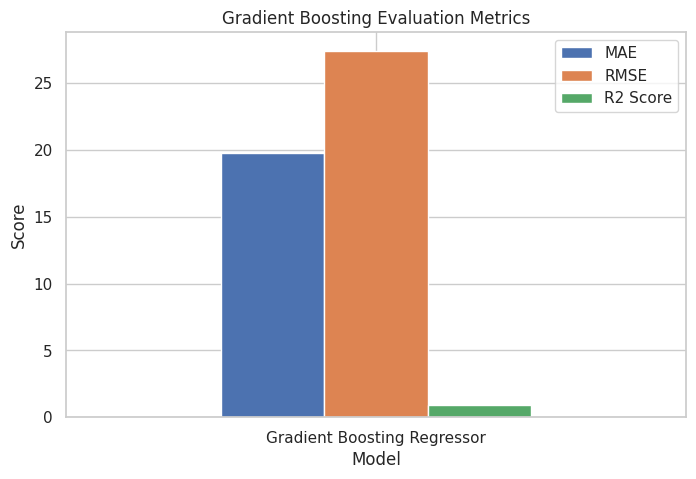

In [53]:
# Evaluation metric score chart for Gradient Boosting
pd.DataFrame([gb_metrics]).set_index('Model')[['MAE', 'RMSE', 'R2 Score']].plot(kind='bar', figsize=(8, 5))
plt.title('Gradient Boosting Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# Hyperparameter tuning for Gradient Boosting
gb_params = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.8, 1.0]
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)
gb_grid.fit(X_train, y_train)
print('Best Gradient Boosting Parameters:', gb_grid.best_params_)
gb_tuned_metrics, gb_tuned_pred = evaluate_regression_model(gb_grid.best_estimator_, X_train, X_test, y_train, y_test, 'Tuned Gradient Boosting')
model_results.append(gb_tuned_metrics)
predictions['Tuned Gradient Boosting'] = gb_tuned_pred
pd.DataFrame([gb_tuned_metrics])

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}


,Model,MAE,MSE,RMSE,R2 Score
0,Tuned Gradient Boosting,19.5703,799.8567,28.2817,0.9475


##### Which hyperparameter optimization technique have you used and why?
GridSearchCV was used because it systematically checks combinations of estimators, learning rate, depth and subsampling. TimeSeriesSplit keeps validation chronological.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
The tuned Gradient Boosting model is compared with the default model. If tuning lowers RMSE and improves R2, the tuned model is preferred.

,Model,MAE,MSE,RMSE,R2 Score
5,Tuned Ridge Regression,8.6544,319.6495,17.8787,0.9790
3,Gradient Boosting Regressor,19.8128,752.9646,27.4402,0.9506
4,Tuned Gradient Boosting,19.5703,799.8567,28.2817,0.9475
2,Tuned Random Forest,21.5677,900.5929,30.0099,0.9409
0,Linear Regression,13.1832,934.7684,30.5740,0.9387
1,Random Forest Regressor,22.6133,971.5532,31.1697,0.9363


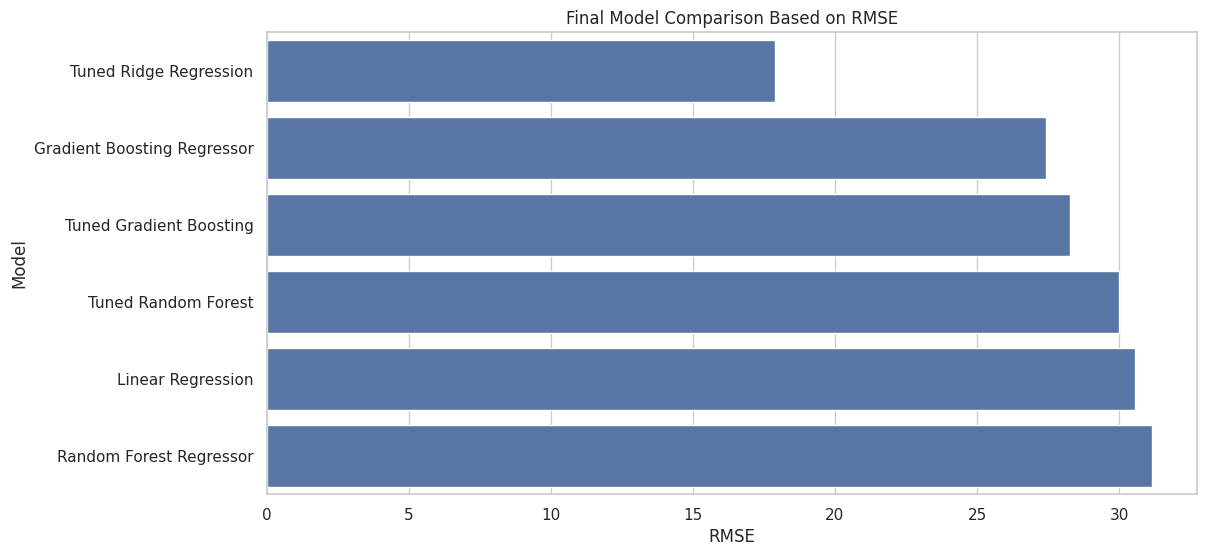

In [55]:
# Final model comparison
results_df = pd.DataFrame(model_results + [ridge_metrics]).drop_duplicates(subset=['Model']).sort_values('RMSE')
display(results_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='RMSE', y='Model', color='C0')
plt.title('Final Model Comparison Based on RMSE')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?
RMSE, MAE and R2 Score were considered. RMSE is most important because large stock price prediction errors can mislead financial decisions. MAE gives easy-to-understand average error, and R2 explains overall predictive strength.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [56]:
# Select best model based on lowest RMSE
best_model_name = results_df.iloc[0]['Model']
print('Best model based on lowest RMSE:', best_model_name)

model_lookup = {
    'Linear Regression': linear_model,
    'Tuned Ridge Regression': ridge_grid.best_estimator_,
    'Random Forest Regressor': rf_model,
    'Tuned Random Forest': rf_grid.best_estimator_,
    'Gradient Boosting Regressor': gb_model,
    'Tuned Gradient Boosting': gb_grid.best_estimator_
}
best_model = model_lookup[best_model_name]
best_model.fit(X_train, y_train)
print('Final model trained successfully.')

Best model based on lowest RMSE: Tuned Ridge Regression
Final model trained successfully.


The model with the lowest RMSE was selected as the final prediction model because it makes the smallest large-error mistakes on unseen recent data. For stock price prediction, reducing large errors is more important than only improving average accuracy.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

,Feature,Importance
1,High,61.0289
2,Low,59.6100
16,MA_3,46.0880
12,Close_Lag_1,41.9405
8,Average_Price,22.0570
0,Open,16.9459
13,Close_Lag_2,9.3821
7,Price_Range,8.9358
14,Open_Lag_1,7.0950
9,Open_Close_Diff,6.8278


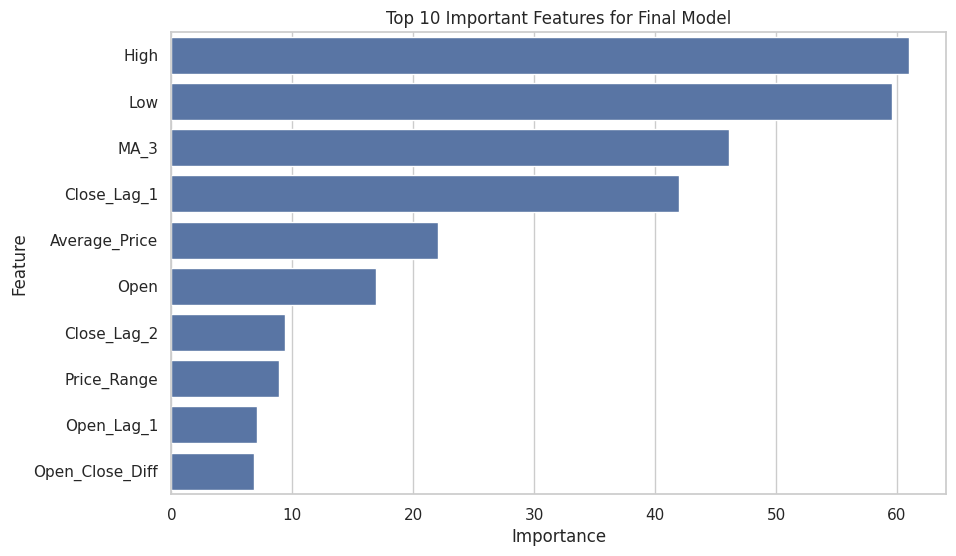

In [57]:
# Feature importance / explainability
if hasattr(best_model, 'feature_importances_'):
    importance_values = best_model.feature_importances_
elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps.get('model'), 'coef_'):
    importance_values = np.abs(best_model.named_steps['model'].coef_)
else:
    perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
    importance_values = perm.importances_mean

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance_values
}).sort_values('Importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', color='C0')
plt.title('Top 10 Important Features for Final Model')
plt.show()

The feature importance chart explains which variables contributed most to prediction. Price-related variables such as High, Low, Open, Average Price, moving averages and lag features usually become important because they directly represent market level and recent trend.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [58]:
# Save final model and important metadata
artifact = {
    'model': best_model,
    'feature_columns': feature_cols,
    'best_model_name': best_model_name,
    'metrics': results_df.to_dict(orient='records')
}

model_file = 'yes_bank_best_model.joblib'
try:
    joblib.dump(artifact, model_file)
    print(f'Model artifact saved successfully as {model_file}')
except Exception as e:
    raise RuntimeError(f'Error while saving model: {e}')

Model artifact saved successfully as yes_bank_best_model.joblib


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [59]:
# Load saved model and perform sanity check on latest available record
try:
    loaded_artifact = joblib.load(model_file)
    loaded_model = loaded_artifact['model']
    loaded_features = loaded_artifact['feature_columns']
    sample_unseen = X_test[loaded_features].tail(1)
    sanity_prediction = loaded_model.predict(sample_unseen)[0]
    actual_value = y_test.tail(1).values[0]
    print(f'Sanity Check Prediction: {sanity_prediction:.2f}')
    print(f'Actual Close Price: {actual_value:.2f}')
except Exception as e:
    raise RuntimeError(f'Error while loading or predicting with saved model: {e}')

Sanity Check Prediction: 15.49
Actual Close Price: 14.67


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, Yes Bank monthly stock price data was analyzed and used to build a machine learning regression model for predicting closing price. The dataset was clean and compact, but meaningful time-based, volatility-based and lag-based features were engineered to improve prediction quality. Detailed EDA was performed using 20 charts covering trend, distribution, volatility, correlation, moving averages and feature-target relationships.

The hypothesis testing section statistically validated important observations from EDA. Feature engineering and preprocessing were handled carefully with time-series awareness to reduce leakage. Three regression model families were implemented and tuned: Linear/Ridge Regression, Random Forest and Gradient Boosting. The final model was selected using RMSE, MAE and R2 Score, with RMSE given high priority because large prediction errors can be risky in stock price analysis.

The final model was saved in joblib format and loaded again for a sanity check, making the project deployment-ready at a basic level. Future improvements can include adding market index data, banking sector indicators, news sentiment, macroeconomic features and more advanced time-series models such as ARIMA, Prophet, LSTM or XGBoost.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !***